In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
from scipy.optimize import curve_fit
import sys
sys.path.append('/Users/lkbayne/Desktop/python/tools')
import chem_calcs as cc
import pingouin as pg

In [3]:
#import pFI files
files = ['DAY0.txt', 'DAY7.txt', 'DAY14.txt', 'DAY21.txt', 'DAY35.txt', 'DAY96.txt']

#fix sample names since i manually named them all differently
Si_fixes = {"A2": "A2_Si", "A3": "A3_Si", "A4": "A4_Si", "B2": "B2_Si", "B3": "B3_Si", "B4": "B4_Si", "C2": "C2_Si", "C3": "C3_Si", "C4": "C4_Si", "D1": "D1_Si", "D2": "D2_Si"}
P_fixes = {"A1_P": "A1_PO4", "A3_P": "A3_PO4", "A4_P": "A4_PO4", "B1_P": "B1_PO4", "B3_P": "B3_PO4", "B4_P": "B4_PO4", "C1_P": "C1_PO4", "C3_P": "C3_PO4", "C4-P": "C4_PO4", "D1_P": "D1_PO4", "D2_P": "D2_PO4"}

Si_samples = list(Si_fixes.values())
P_samples = list(P_fixes.values())

#calcultaing Si standard concentration input (concentration, spike, new concentation, new bottle volume)
Si_conc = cc.conc_to_dil(10255, 220, None, 50 * 1000)
P_conc = cc.conc_to_dil(4997.89, 40, None, 50*1000)

#calculating pFI calibration dilutions that will be used for calibration curve
dilutions = np.array([0, (600-450)/600, (600-300)/600, (600-150)/600, (600-50)/600])
dil_series = np.repeat(dilutions, 3)
Si_cali_concs = dil_series * Si_conc
P_cali_concs = dil_series * P_conc

In [4]:
#Si calculations
#creating data frame
Si_df = []
#for each file take the number from the .txt file name for the day
for file in files:
    day = int(file.replace('DAY', '').replace('.txt', ''))
    #filter txt file for needed information only
    df = pd.read_csv(file, sep="\t")
    df = df[['Name', 'AVE810_1050', 'Sequence Name']].copy()
    df['Name'] = df['Name'].replace(Si_fixes)
    
    #get the specific Si absorbance of each sample
    Si_cali_abs = df.loc[df['Sequence Name'] == "AutoCalibration_Silicate", 'AVE810_1050'].to_numpy()

    #create calibration curve for the day
    fit = stats.linregress(Si_cali_concs, Si_cali_abs)
    slope = fit.slope
    yint = fit.intercept
    slope_err = fit.stderr
    yint_err = fit.intercept_stderr
    #calculating uncertainity variables to calculate error
    predicted = slope * Si_cali_concs + yint
    residuals = Si_cali_abs - predicted
    Sxo = np.sqrt(np.sum(residuals**2) / (len(Si_cali_concs) - 2))

    #calculate Si concentrations from the mean absorbances (3 replicates)
    for sample in Si_samples:
        avg_abs = df.loc[df['Name'] == sample, 'AVE810_1050'].mean()
        conc, u_combined = cc.calc_Si_conc_and_uncert(avg_abs, yint, slope, Sxo, slope_err, yint_err)
        Si_df.append({'Sample': sample, 'Day': day, 'Concentration (uM)': conc, 'Uncertainty': u_combined})

#fill a final data frame
Si_results = pd.DataFrame(Si_df)
Si_results = Si_results.sort_values(by=['Sample', 'Day']).reset_index(drop=True)
print(Si_results)

   Sample  Day  Concentration (uM)  Uncertainty
0   A2_Si    0           40.835306     0.712159
1   A2_Si    7           41.003563     0.825608
2   A2_Si   14           41.019544     0.638724
3   A2_Si   21           40.852048     0.544300
4   A2_Si   35           41.712118     0.734130
..    ...  ...                 ...          ...
61  D2_Si    7           41.132688     0.826373
62  D2_Si   14           41.004475     0.638655
63  D2_Si   21           41.137357     0.545413
64  D2_Si   35           40.392014     0.727215
65  D2_Si   96           41.651567     0.719219

[66 rows x 4 columns]


In [5]:
#P calculations
#creating data frame
P_df = []

#for each file take the number from the .txt file name for the day
for file in files:
    day = int(file.replace('DAY', '').replace('.txt', ''))
    #filter txt file for needed information
    df = pd.read_csv(file, sep="\t")
    df = df[['Name', 'AVE880_1050', 'Sequence Name']].copy()
    df['Name'] = df['Name'].replace(P_fixes)

    #get absorbance of each sample at specific wavelength
    P_cali_abs = df.loc[df['Sequence Name'] == "Autocalibration_Phosphate", 'AVE880_1050'].to_numpy()
        
    #create calibration curve for the day
    fit = np.polyfit(P_cali_concs, P_cali_abs, 2)
    a, b, c = fit
    
    #get uncertainity variables to calculate error
    P_predicted_abs = a * P_cali_concs**2 + b * P_cali_concs + c

    #Residuals: observed - predicted
    P_residuals = P_cali_abs - P_predicted_abs

    #Sxo for PO4
    n_P = len(P_cali_concs)
    Sxo_P = np.sqrt(np.sum(P_residuals**2) / (n_P - 3))

    #calculate Si concentrations from the mean absorbances
    for sample in P_samples:
        avg_abs = df.loc[df['Name'] == sample, 'AVE880_1050'].mean()

        if avg_abs == avg_abs:  #skips NaN values in .txt file
            conc, u_combined = cc.calc_PO4_conc_and_uncert(avg_abs, a, b, c, Sxo_P)
            P_df.append({'Sample': sample, 'Day': day, 'Concentration (uM)': conc, 'Uncertainty': u_combined})

#concentration data frame
P_results = pd.DataFrame(P_df)
P_results = P_results.sort_values(by=['Sample', 'Day']).reset_index(drop=True)
print(P_results)

    Sample  Day  Concentration (uM)  Uncertainty
0   A1_PO4    0            2.020812     0.070329
1   A1_PO4    7            2.035876     0.102070
2   A1_PO4   14            2.015423     0.077673
3   A1_PO4   21            2.062938     0.072873
4   A1_PO4   35            1.949597     0.060911
..     ...  ...                 ...          ...
61  D2_PO4    7            2.065057     0.101266
62  D2_PO4   14            1.962000     0.078454
63  D2_PO4   21            2.080136     0.072622
64  D2_PO4   35            2.014651     0.060319
65  D2_PO4   96            1.982981     0.049358

[66 rows x 4 columns]


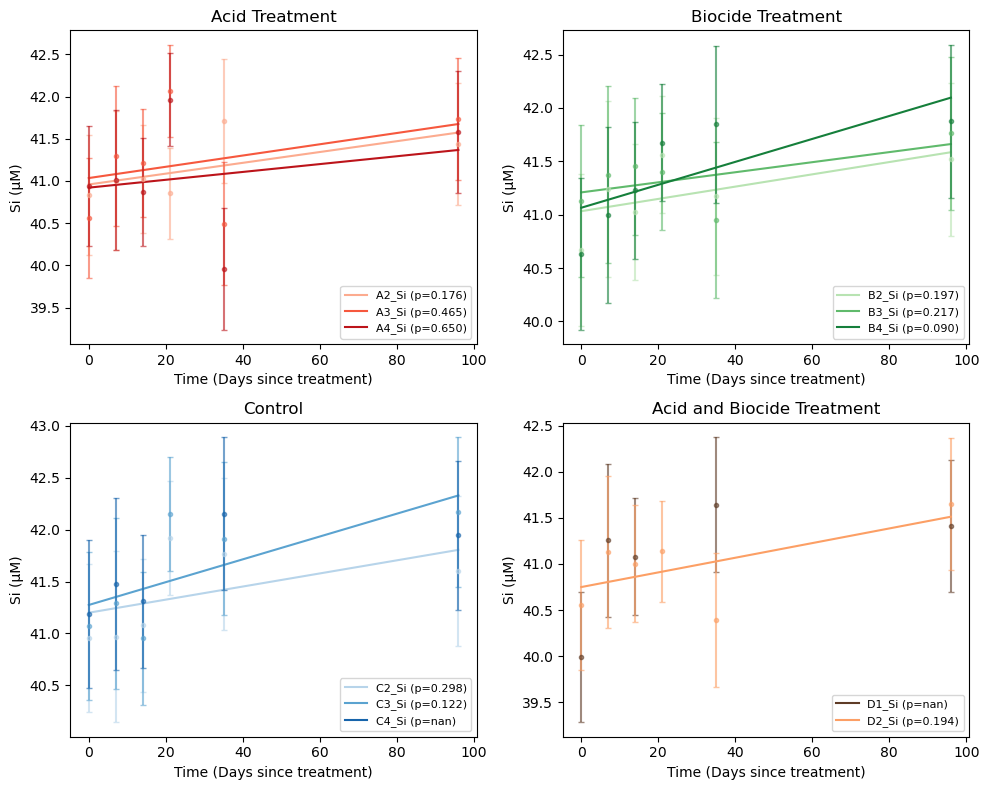

In [31]:
#Si graphs of concentration over time
Si_results['Row'] = Si_results['Sample'].str[0]

#label and assign colors to treatment groups
labels = {'A': 'Acid Treatment', 'B': 'Biocide Treatment', 'C': 'Control', 'D': 'Acid and Biocide Treatment'}
colormaps = {'A': plt.cm.Reds, 'B': plt.cm.Greens, 'C': plt.cm.Blues, 'D': plt.cm.copper}

#graph
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

#each treatment
for i, row in enumerate(['A', 'B', 'C', 'D']):
    ax = axes[i]
    data = Si_results[Si_results['Row'] == row]
    samples = data['Sample'].unique()
    cmap = colormaps[row]
    sample_colors = dict(zip(samples, cmap(np.linspace(0.3, 0.8, len(samples)))))

    #each sample with errors
    for sample in samples:
        s = data[data['Sample'] == sample]
        color = sample_colors[sample]
        ax.errorbar(s['Day'], s['Concentration (uM)'], yerr=s['Uncertainty'], fmt='.', color=color, alpha=0.6, capsize=2)

        #sample trend line
        if len(s) >= 2:
            x = s['Day']
            y = s['Concentration (uM)']
            slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
            if p_value < 0.05:
                print(f"{sample} is significant: p = {p_value:.4f}")
            x_fit = np.linspace(x.min(), x.max(), 100)
            y_fit = slope * x_fit + intercept
            ax.plot(x_fit, y_fit, '-', color=color, label=f'{sample} (p={p_value:.3f})')

    ax.set_title(labels[row])
    ax.set_xlabel('Time (Days since treatment)')
    ax.set_ylabel('Si (µM)')
    ax.legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.show()

In [ ]:
#graphs of PO4 concentration over time
P_results['Row'] = P_results['Sample'].str[0]

#label and assign colors to treatment groups
labels = {'A': 'Acid Treatment', 'B': 'Biocide Treatment', 'C': 'Control', 'D': 'Acid and Biocide Treatment'}
colormaps = {'A': plt.cm.Reds, 'B': plt.cm.Greens, 'C': plt.cm.Blues, 'D': plt.cm.copper}

#graph
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

#each treatment
for i, row in enumerate(['A', 'B', 'C', 'D']):
    ax = axes[i]
    data = P_results[P_results['Row'] == row]
    samples = data['Sample'].unique()
    cmap = colormaps[row]
    sample_colors = dict(zip(samples, cmap(np.linspace(0.3, 0.8, len(samples)))))

    #each sample with errors
    for sample in samples:
        s = data[data['Sample'] == sample]
        color = sample_colors[sample]
        ax.errorbar(s['Day'], s['Concentration (uM)'], yerr=s['Uncertainty'], fmt='.', color=color, alpha=0.6, capsize=2)

        #sample trend line
        if len(s) >= 2:
            x = s['Day']
            y = s['Concentration (uM)']
            slope, intercept, r_value, p_value, _ = stats.linregress(x, y)
            if p_value < 0.05:
                print(f"{sample} is significant: p = {p_value:.4f}")
            x_fit = np.linspace(x.min(), x.max(), 100)
            y_fit = slope * x_fit + intercept
            ax.plot(x_fit, y_fit, '-', color=color, label=f'{sample} (p={p_value:.3f})')

    ax.set_title(labels[row])
    ax.set_xlabel('Time (Days since treatments)')
    ax.set_ylabel('PO4 (µM)')
    ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

In [17]:
#errors with C4 and D1 bc one of the three replicates is bad so i need to figure out a way to take those out and only use the two good points
#also something wrong with Si code bc p-values dont match the graphs

#moving forward i want to do a paired t-test from the start (day 0) to the end point (day 96)
#also a replicates ANOVA but im having a hard time with the random bad data points...

In [24]:
#paired t-test comparing day 0 and day 96 for each sample
# Filter to just the two days you want to compare


In [23]:
#paired t-test comparing day 0 and day 96 for each sample
#start_day = 0
#end_day = 96

#for sample in Si_absorbances['Sample'].unique():
#    s = Si_absorbances[Si_absorbances['Sample'] == sample]

#    #t_stat, p_val = ttest_rel(reps_start_day, reps_end_day)


In [22]:
#ANOVA = pg.rm_anova(dv='Absorbance', within='Day', subject='Replicate', data=s, detailed=True)
 